# Timetable-driven arrival burstiness

The main focus is the **timing pattern of arrivals**.

The key comparison is:

- the **same total number of cars** arrive in both scenarios;
- one scenario has cars arriving close together before class;
- the other spreads the same cars across a longer time window.

### Main research question

**How does the concentration of vehicle arrivals affect parking congestion when total demand is unchanged?**


In [1]:
# Path helps the notebook find the project root whether Jupyter starts from
# the repository root or from inside the notebooks folder.
from pathlib import Path

# sys lets us add the repository root to Python's import path.
import sys

# Find the repository root.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Add the repository root only if Python cannot already see it.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Import the experiment functions written in src/experiments.py.
from src.experiments import run_burst_sweep, run_condition

# Import the plotting helpers written in utils/plots.py.
from utils.plots import (
    read_csv_rows,
    plot_arrival_patterns,
    plot_backlog_comparison,
    plot_burst_heatmap,
    plot_burst_interaction,
)


## Experiment design

The main sweep changes three variables:

1. **Arrival window width:** 10, 20, 40, 60 simulation steps. A smaller width means the cars are more synchronised.
2. **Total arriving cars:** 12, 18, 24.
3. **Mean parking duration:** 15, 30, 60 simulation steps.

For a fair burstiness comparison, the total number of cars stays the same when we compare different arrival-window widths.

Each condition is repeated with 10 random seeds.

So the main sweep contains:

**4 × 3 × 3 × 10 = 360 simulation runs.**


In [2]:
# The experiment writes its averaged results to this CSV file.
summary_path = repo_root / "data" / "burst_sweep_summary.csv"

# If the file does not exist yet, run the full parameter sweep first.
if not summary_path.exists():
    run_burst_sweep(repo_root / "data")

# Read the averaged results into a list of dictionaries for plotting.
summary_rows = read_csv_rows(summary_path)

# Show how many averaged parameter conditions were loaded.
len(summary_rows)


36

## Figure 1 - What does “bursty arrival” mean?

Both lines below contain **24 total arriving cars**.

The difference is only timing:

- width 10: the cars are concentrated into a short period;
- width 60: the same cars are spread across a longer period.


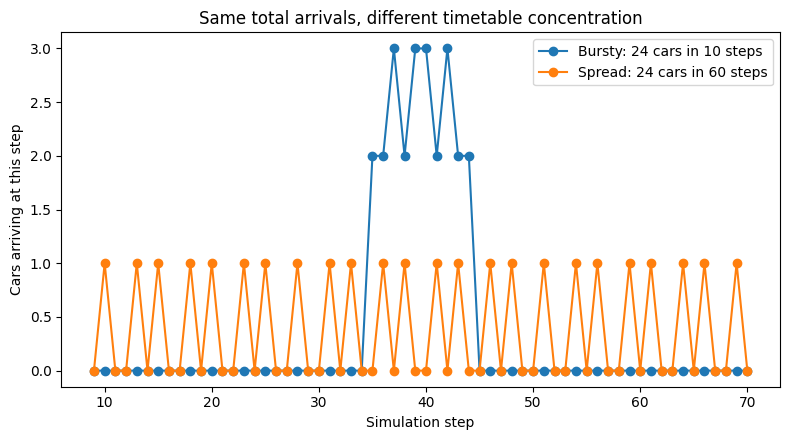

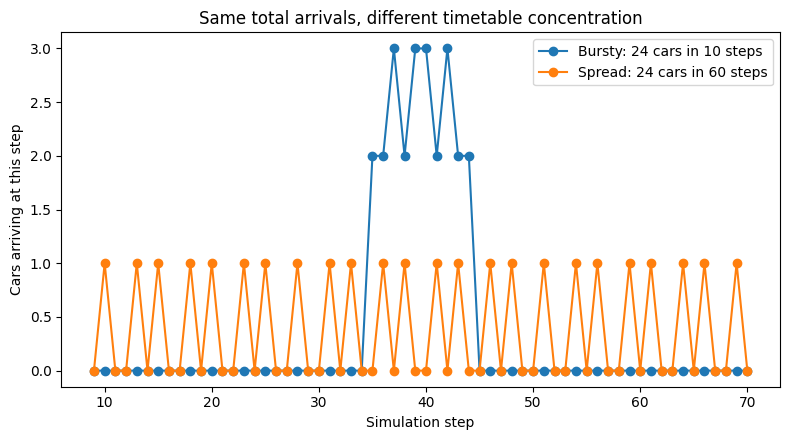

In [3]:
# Draw the exact arrival schedules used by the simulation.
plot_arrival_patterns(
    total_arrivals=24,
    bursty_width=10,
    spread_width=60,
)


## Figure 2 - Same total arrivals, different congestion

For this matched example we keep the following settings identical:

- 24 total arrivals;
- mean parking duration = 30;
- random seed = 3;
- same car-park layout and starting occupancy.

Only the arrival-window width changes.


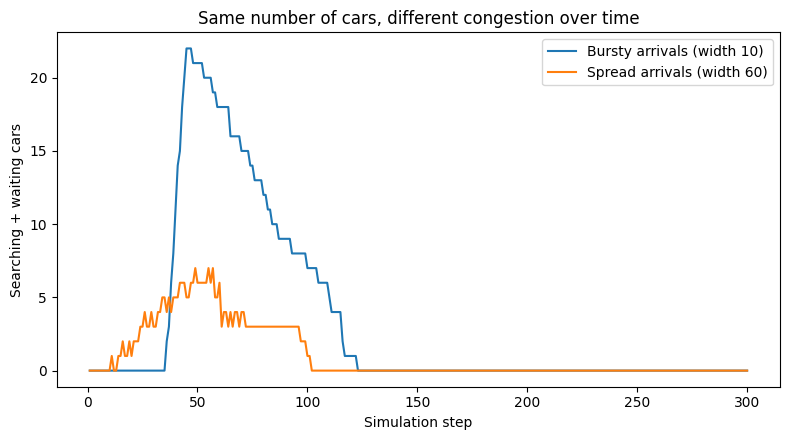

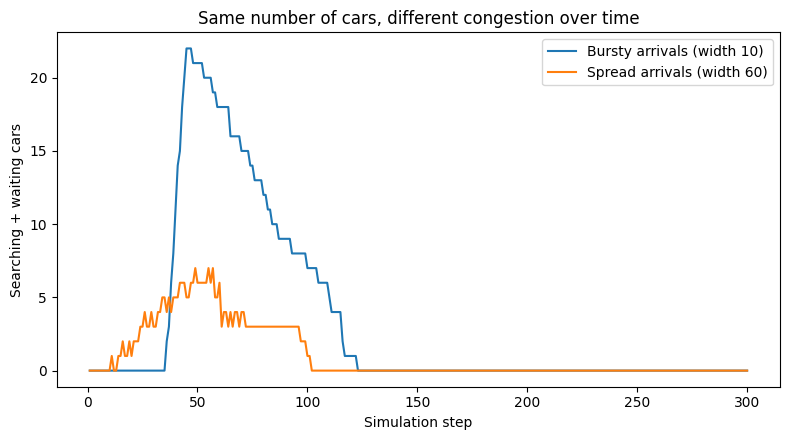

In [4]:
# Run the concentrated-arrival case and keep the full model for plotting.
_, bursty_model = run_condition(
    burst_width=10,
    total_arrivals=24,
    mean_parking_duration=30,
    seed=3,
    return_model=True,
)

# Run the spread-arrival case with the same settings and the same random seed.
_, spread_model = run_condition(
    burst_width=60,
    total_arrivals=24,
    mean_parking_duration=30,
    seed=3,
    return_model=True,
)

# Compare searching + outside waiting over time.
plot_backlog_comparison(bursty_model, spread_model)


The total number of arriving cars is identical in both runs. The bursty case creates a much higher backlog because many cars reach the parking system at nearly the same time.


## Figure 3 - Burstiness across different demand levels

The heatmap below fixes mean parking duration at 30 steps.

Each row uses a different total number of arriving cars. Within each row, that total stays fixed while the arrival-window width changes.


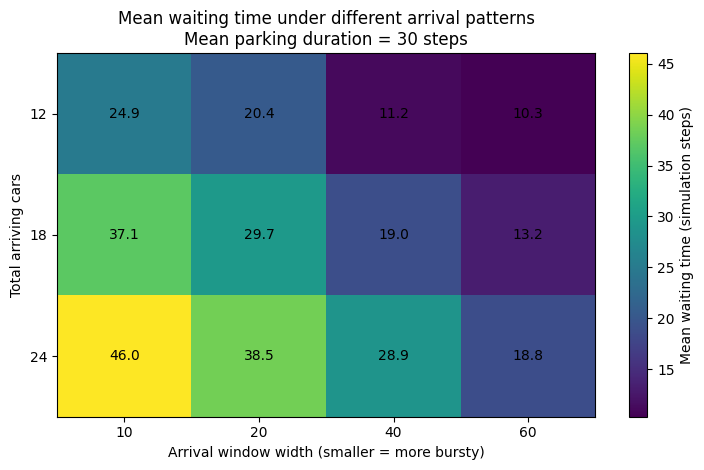

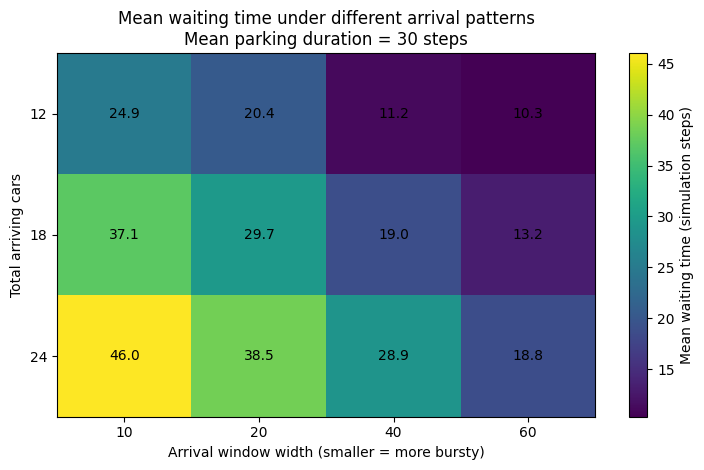

In [5]:
# Plot mean waiting time for several burst widths and total-demand levels.
plot_burst_heatmap(
    summary_rows,
    mean_parking_duration=30,
)


## Figure 4 - Interaction with parking duration

The next plot fixes total arrivals at 24 cars.

It shows whether the burstiness effect changes when parking spaces turn over more quickly or more slowly.


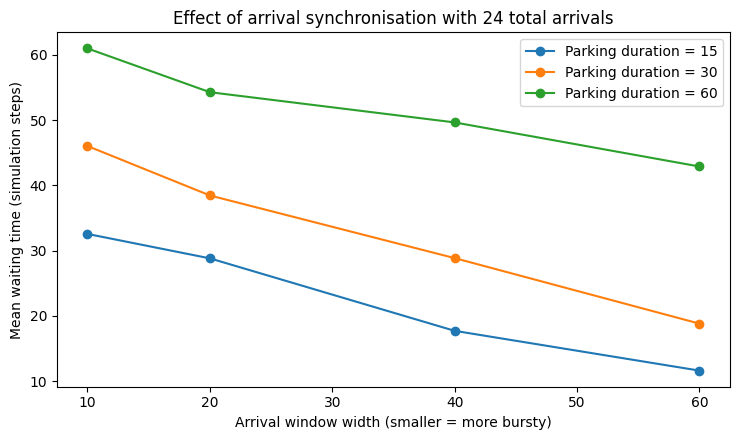

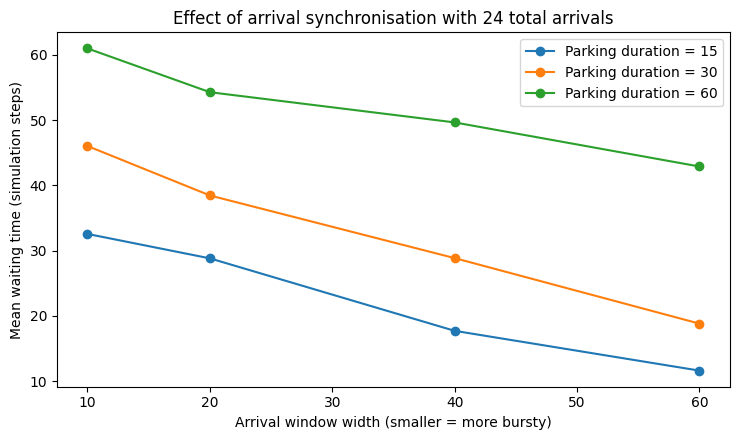

In [6]:
# Plot burst width against mean waiting time for three parking durations.
plot_burst_interaction(
    summary_rows,
    total_arrivals=24,
)


## Preliminary result

For **24 total arrivals** and **mean parking duration = 30**:

- arrival width 10: mean waiting time ≈ **46.0 steps**, peak backlog ≈ **22.0 cars**;
- arrival width 60: mean waiting time ≈ **18.8 steps**, peak backlog ≈ **8.2 cars**.

The total number of arriving cars is the same in both cases.

This supports the idea that the **temporal concentration of demand** can strongly change parking-search congestion, even when the total demand being compared is unchanged.


## Limitations and next steps

- The layout is a simplified loop rather than a real campus car park.
- Entry control can be studied later as an intervention to see whether it reduces burst congestion or just moves the queue outside.
